In [35]:
import os
import json
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerTuple

from src.config import MODEL_CLASSES
import src.api.result as result_api

RESULTS_DIR = "results"

# Shuffle

In [40]:
def load_results_shuffle(model_name, component):
    fname = f"{model_name}_symbol_20_shuffle_{component}.json"
    result_path = os.path.join(RESULTS_DIR, fname)
    with open(result_path, "r") as f:
        results = json.load(f)

    results = [result_api.ICLResult(**r) for r in results]

    return results

def summarise_results_shuffle(results):
    d = {}

    for r in results:
        if "shuffle_meta" in r.model_details:
            shuffle_meta = r.model_details["shuffle_meta"]
            shuffle_type = shuffle_meta["shuffled_type"]
            if shuffle_type not in d:
                d[shuffle_type] = {"accuracy": []}
            d[shuffle_type]["accuracy"].append(r.accuracy)

        else:
            d["original"] = {"accuracy": r.accuracy}

    for shuffle_type in d:
        d[shuffle_type] = {
            "mean": np.mean(d[shuffle_type]["accuracy"]),
            "std": np.std(d[shuffle_type]["accuracy"]),
        }

    return d

def collect_all_models():
    d_all_qk = {}
    d_all_ov = {}
    for model_name in MODEL_CLASSES:
        results = load_results_shuffle(model_name, "qk")
        d = summarise_results_shuffle(results)
        d_all_qk[model_name] = d

    for model_name in MODEL_CLASSES:
        results = load_results_shuffle(model_name, "ov")
        d = summarise_results_shuffle(results)
        d_all_ov[model_name] = d

    return d_all_qk, d_all_ov


def aggregate_shuffle_results(d_qk, d_ov):
    cmap = matplotlib.cm.get_cmap("brg")
    colors = [cmap(t) for t in np.linspace(0, 0.9, len(MODEL_CLASSES))]

    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    label_handle = []
    label_names = []
    for i, model_name in enumerate(MODEL_CLASSES):
        d_model = d_qk[model_name]
        mu_original = d_model["original"]["mean"]
        mu_inside = d_model["inside"]["mean"]
        mu_outside = d_model["outside"]["mean"]

        print(model_name, "qk")
        print(mu_original, mu_inside, mu_outside)

        p1 = ax.scatter(
            (mu_original - mu_inside) / mu_original,
            (mu_original - mu_outside) / mu_original,
            marker="+",
            color=colors[i],
            s=100,
            label=model_name + " qk",
        )

        d_model = d_ov[model_name]
        mu_original = d_model["original"]["mean"]
        mu_inside = d_model["inside"]["mean"]
        mu_outside = d_model["outside"]["mean"]

        print(model_name, "ov")
        print(mu_original, mu_inside, mu_outside)

        p2 = ax.scatter(
            (mu_original - mu_inside) / mu_original,
            (mu_original - mu_outside) / mu_original,
            marker="x",
            color=colors[i],
            s=100,
            label=model_name + " ov",
        )
        label_handle.append((p1, p2))
        label_names.append(model_name + " QK/OV")

    ax.set_xlim((0 - 0.1, 1))
    ax.set_ylim((0 - 0.1, 1))
    l = ax.legend(
        label_handle, label_names, handler_map={tuple: HandlerTuple(ndivide=None)}
    )
    title = (
        "Reduced prob of predicting correct token"
        if type == "prob"
        else "Reduced acc of predicting correct token"
    )
    ax.set_title(title, weight="bold", fontsize=12)
    ax.set_xlabel("Shuffle heads within", weight="bold", fontsize=14)
    ax.set_ylabel("Shuffle heads outside", weight="bold", fontsize=14)
    plt.savefig(os.path.join(RESULTS_DIR, "shuffle_summary.png"), bbox_inches="tight")
    plt.show()


/tmp/ipykernel_2120087/1426951325.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap("brg")


gpt2 qk
0.52 0.54 0.08199999999999999
gpt2 ov
0.52 0.5539999999999999 0.22199999999999998
gpt2-xl qk
0.85 0.86 0.462
gpt2-xl ov
0.85 0.8320000000000001 0.634
llama2-7b qk
0.85 0.692 0.6220000000000001
llama2-7b ov
0.81 0.8160000000000001 0.768
llama3-8b qk
0.96 0.75 0.406
llama3-8b ov
0.96 0.726 0.6
gemma-7b qk
0.97 0.9380000000000001 0.8320000000000001
gemma-7b ov
0.97 0.908 0.6
gemma2-9b qk
0.93 0.8460000000000001 0.8400000000000001
gemma2-9b ov
0.93 0.8699999999999999 0.876
falcon-7b qk
0.84 0.8379999999999999 0.434
falcon-7b ov
0.84 0.8400000000000001 0.5359999999999999
mistral-7b qk
0.94 0.828 0.75
mistral-7b ov
0.94 0.8859999999999999 0.85
olmo-7b qk
0.9 0.8320000000000001 0.568
olmo-7b ov
0.9 0.772 0.506
pythia-7b qk
0.77 0.8220000000000001 0.736
pythia-7b ov
0.77 0.6019999999999999 0.384


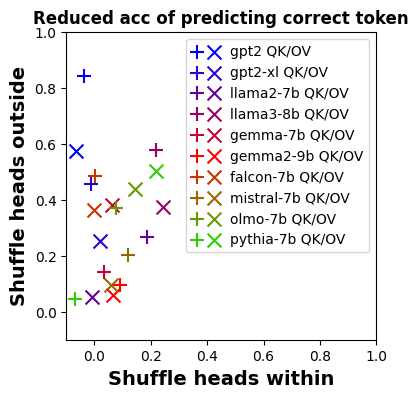

In [41]:
d_qk, d_ov = collect_all_models()
aggregate_shuffle_results(d_qk, d_ov)

# Project

In [30]:
def load_results_projection(model_name, component):
    fname = f"{model_name}_symbol_20_projection_{component}.json"
    result_path = os.path.join(RESULTS_DIR, fname)
    with open(result_path, "r") as f:
        results = json.load(f)

    return results

/tmp/ipykernel_2120087/3705317330.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap("brg")


gpt2 50 0.52 0.2 0.46
gpt2-xl 80 0.85 0.06 0.62
llama2-7b 200 0.78 0.29 0.48
llama3-8b 200 0.96 0.15 0.26
gemma-7b 150 0.97 0.06 0.88
gemma2-9b 170 0.93 0.56 0.39
falcon-7b 220 0.84 0.3 0.06
mistral-7b 200 0.94 0.4 0.5
olmo-7b 200 0.9 0.0 0.56
pythia-7b 200 0.77 0.23 0.49


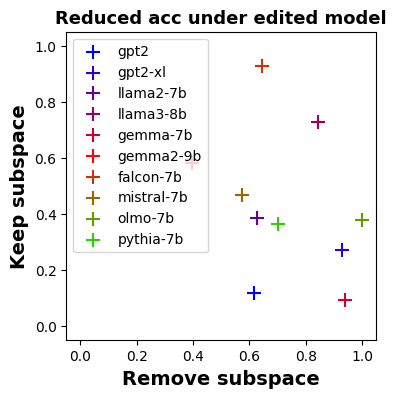

In [31]:
def plot_projection_results():
    import matplotlib
    from matplotlib.legend_handler import HandlerTuple
    from src.config import MODEL_CLASSES, MODEL_META

    cmap = matplotlib.cm.get_cmap("brg")
    colors = [cmap(t) for t in np.linspace(0, 0.9, len(MODEL_CLASSES))]

    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    label_handle = []
    label_names = []
    for i, model_name in enumerate(MODEL_CLASSES.keys()):
        try:
            hidden_size = MODEL_META[model_name]["hidden_size"]
            K = max(50, int(0.05 * hidden_size / 10) * 10)
            proj_true_result, proj_false_result = load_results_projection(
                model_name, "qk"
            )

            baseline = proj_true_result["result"][str(0)]["acc"]
            proj_true_acc = proj_true_result["result"][str(K)]["acc"]
            proj_false_acc = proj_false_result["result"][str(K)]["acc"]

            print(model_name, K, baseline, proj_true_acc, proj_false_acc)

            p1 = ax.scatter(
                (baseline - proj_true_acc) / baseline,
                (baseline - proj_false_acc) / baseline,
                marker="+",
                s=100,
                color=colors[i],
            )
            label_handle.append((p1))
            label_names.append(model_name)
        except Exception as e:
            print(model_name, "not found", e)

    ax.set_xlim((0 - 0.05, 1 + 0.05))
    ax.set_ylim((0 - 0.05, 1 + 0.05))
    l = ax.legend(
        label_handle, label_names, handler_map={tuple: HandlerTuple(ndivide=None)}
    )
    ax.set_title("Reduced acc under edited model", weight="bold", fontsize=13)
    ax.set_xlabel("Remove subspace", weight="bold", fontsize=14)
    ax.set_ylabel("Keep subspace", weight="bold", fontsize=14)
    plt.savefig(
        os.path.join(RESULTS_DIR, "projection_summary.png"), bbox_inches="tight"
    )
    plt.show()


plot_projection_results()